# 02 - Exploratory data analysis (extended)

This notebook expands the exploratory analysis to cover a broader set of
variables, including the controls module (irrigation, machinery, seed use,
training/credit/education). It focuses on distributional patterns, missingness,
group differences, and simple bivariate relationships that motivate modeling
choices.

In [9]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Setup

In [10]:
SAVE_PLOTS = False
RANDOM_SEED = 42


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for parent in [start] + list(start.parents):
        if (parent / "src").exists() and (parent / "data").exists():
            return parent
    raise RuntimeError("Could not locate repo root. Run from within the repo.")


REPO_ROOT = find_repo_root()
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
PLOT_DIR = REPO_ROOT / "outputs" / "plots" / "notebooks"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


ID_COLS = ["anio", "ccdd", "ccpp", "ccdi", "psu", "id_prod", "ua"]


def weighted_mean(series: pd.Series, weights: pd.Series) -> float:
    mask = series.notna() & weights.notna()
    if not mask.any():
        return float("nan")
    return float((series[mask] * weights[mask]).sum() / weights[mask].sum())


def safe_ratio(numer: pd.Series, denom: pd.Series) -> pd.Series:
    out = numer / denom
    out = out.where((denom > 0) & denom.notna())
    return out


def share_zero(series: pd.Series) -> float:
    return float(series.eq(0).mean())

## Load the modeling datasets

We load the base model dataset and (if available) the plus-controls dataset
to extend the analysis to irrigation, machinery, seed, and extension variables.

In [11]:
model_path = PROCESSED_DIR / "model_data_ena2024.parquet"
if not model_path.exists():
    raise FileNotFoundError(f"Missing model dataset: {model_path}")

model = pd.read_parquet(model_path)

controls_path = PROCESSED_DIR / "model_data_ena2024_plus_controls.parquet"
if controls_path.exists():
    model_ctrl = pd.read_parquet(controls_path)
    controls_loaded = True
else:
    model_ctrl = model.copy()
    controls_loaded = False

print("Base shape:", model.shape)
print("Controls shape:", model_ctrl.shape)
print("Controls loaded:", controls_loaded)

Base shape: (35187, 39)
Controls shape: (35187, 77)
Controls loaded: True


## Data overview

Quick structural checks for duplicates, key completeness, and sample sizes.

In [12]:
print("Duplicate key rows (base):", int(model.duplicated(subset=ID_COLS).sum()))
missing_keys = model[ID_COLS].isna().mean().sort_values(ascending=False)
print("Missingness in ID cols:\n", missing_keys)

region_counts = model["region_natural"].value_counts(dropna=False)
size_counts = model["size_cat"].value_counts(dropna=False)
print("\nRegion counts:\n", region_counts)
print("\nSize counts:\n", size_counts)

Duplicate key rows (base): 0
Missingness in ID cols:
 ccdd       0.031603
ccpp       0.031603
ccdi       0.031603
anio       0.000000
psu        0.000000
id_prod    0.000000
ua         0.000000
dtype: float64

Region counts:
 region_natural
2    20601
1     8263
3     6323
Name: count, dtype: int64

Size counts:
 size_cat
pequeno_<2ha     21957
mediano_2_5ha     6278
grande_>5ha       5840
NaN               1112
Name: count, dtype: int64


## Core summary statistics

Summary metrics for economic scale, diversification, and practice adoption.

In [13]:
summary_cols = [
    "valor_total",
    "area_total_ha",
    "labor_total",
    "input_costs",
    "diversificacion_area",
    "num_crops_area",
    "num_practices",
    "practice_any",
]

model[summary_cols].describe(percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
valor_total,31824.0,28857.546883,117440.614154,2.0,180.0,4280.0,121186.9,7077408.0
area_total_ha,34075.0,4.598969,16.42123,0.00033,0.08,1.15,16.8243,725.024
labor_total,29218.0,57.78746,3100.9877,1.0,1.0,6.0,68.0,499260.0
input_costs,29581.0,34294.445218,505304.883151,1.0,50.0,800.0,30600.0,33612372.0
diversificacion_area,34075.0,0.504382,0.280411,0.0,0.0,0.576177,0.848698,0.977444
num_crops_area,34075.0,3.502098,2.474396,1.0,1.0,3.0,8.0,28.0
num_practices,35185.0,1.553503,1.221928,0.0,0.0,2.0,3.0,10.0
practice_any,35185.0,0.776069,0.416882,0.0,0.0,1.0,1.0,1.0


## Missingness profile

Missingness rates for key variables help contextualize later interpretations.

In [14]:
missing_targets = [
    "valor_total",
    "area_total_ha",
    "labor_total",
    "input_costs",
    "diversificacion_area",
    "num_crops_area",
    "practice_any",
]

missing_rates = model[missing_targets].isna().mean().sort_values(ascending=False)
missing_rates

labor_total             0.169637
input_costs             0.159320
valor_total             0.095575
area_total_ha           0.031603
diversificacion_area    0.031603
num_crops_area          0.031603
practice_any            0.000057
dtype: float64

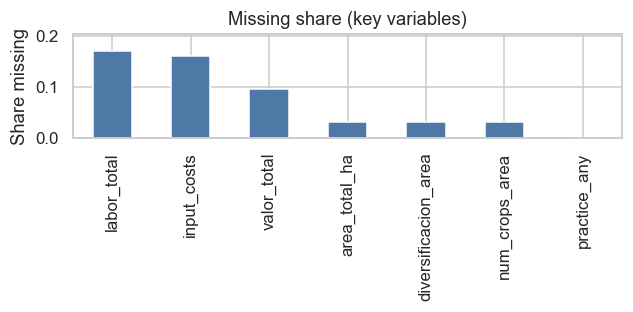

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
missing_rates.plot(kind="bar", ax=ax, color="#4E79A7")
ax.set_title("Missing share (key variables)")
ax.set_ylabel("Share missing")
ax.set_ylim(0, max(0.02, missing_rates.max() * 1.2))
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_missingness_key_vars.png", dpi=150)

## Derived intensity metrics

We build per-hectare measures and log transforms for scale comparisons.

In [16]:
model = model.copy()

model["valor_por_ha"] = safe_ratio(model["valor_total"], model["area_total_ha"])
model["input_costs_por_ha"] = safe_ratio(model["input_costs"], model["area_total_ha"])
model["labor_por_ha"] = safe_ratio(model["labor_total"], model["area_total_ha"])

for col in ["valor_total", "area_total_ha", "input_costs", "labor_total"]:
    model[f"log1p_{col}"] = np.log1p(model[col].where(model[col] >= 0))

model[["valor_por_ha", "input_costs_por_ha", "labor_por_ha"]].describe(percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
valor_por_ha,31824.0,8130.230511,10571.084166,0.357105,245.426834,4994.793124,26198.254109,299866.7259
input_costs_por_ha,28561.0,1427.030332,1613.759100,0.225191,50.000000,846.153846,4648.148148,28825.0000
labor_por_ha,28149.0,37.635694,1648.480038,0.002614,0.312500,5.000000,44.444444,250000.0000


## Distribution of farm sizes and regions

Understanding the sample composition helps interpret regional and scale effects.

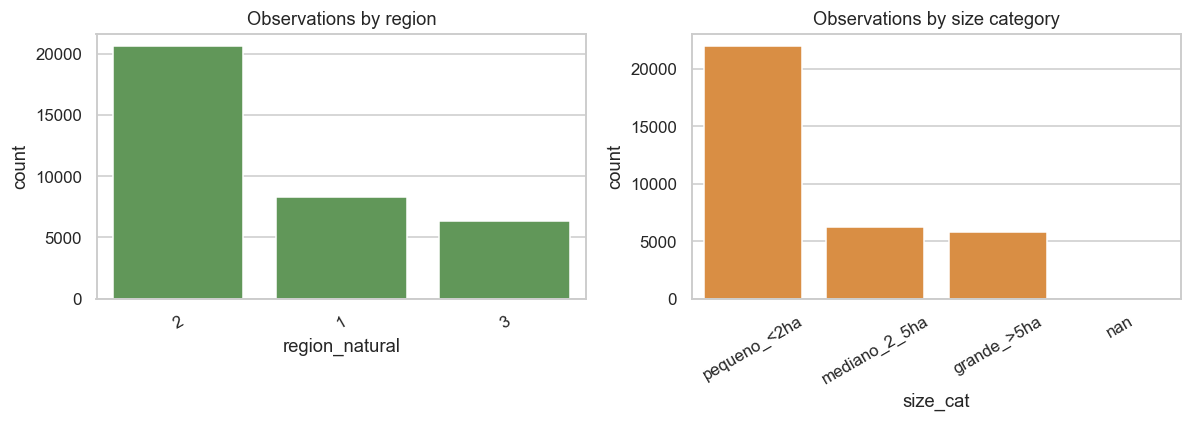

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(
    data=model,
    x="region_natural",
    order=region_counts.index,
    ax=axes[0],
    color="#59A14F",
)
axes[0].set_title("Observations by region")
axes[0].set_xlabel("region_natural")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(
    data=model,
    x="size_cat",
    order=size_counts.index,
    ax=axes[1],
    color="#F28E2B",
)
axes[1].set_title("Observations by size category")
axes[1].set_xlabel("size_cat")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_counts_region_size.png", dpi=150)

## Diversification metrics

We summarize diversification through HHI-based measures and crop counts.

Share monocrop (num_crops_area == 1): 0.205
Share diversification == 0: 0.136


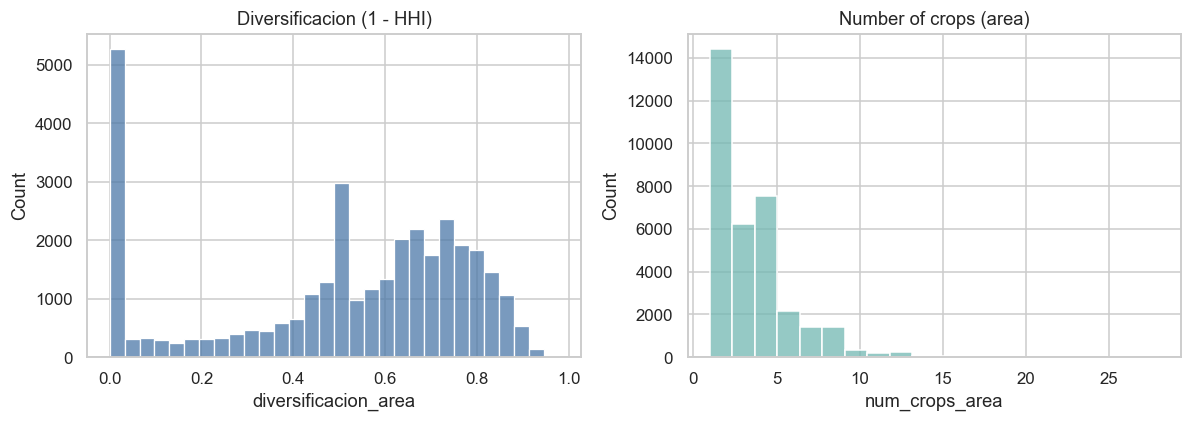

In [18]:
mono_share = float((model["num_crops_area"] == 1).mean())
zero_div_share = float((model["diversificacion_area"] == 0).mean())
print(f"Share monocrop (num_crops_area == 1): {mono_share:.3f}")
print(f"Share diversification == 0: {zero_div_share:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(model["diversificacion_area"], bins=30, ax=axes[0], color="#4C78A8")
axes[0].set_title("Diversificacion (1 - HHI)")
axes[0].set_xlabel("diversificacion_area")

sns.histplot(model["num_crops_area"], bins=20, ax=axes[1], color="#72B7B2")
axes[1].set_title("Number of crops (area)")
axes[1].set_xlabel("num_crops_area")

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_diversification_distribution.png", dpi=150)

Diversification tends to show mass at zero when producers are specialized in
a single crop, which is consistent with HHI = 1 for monocrop observations.

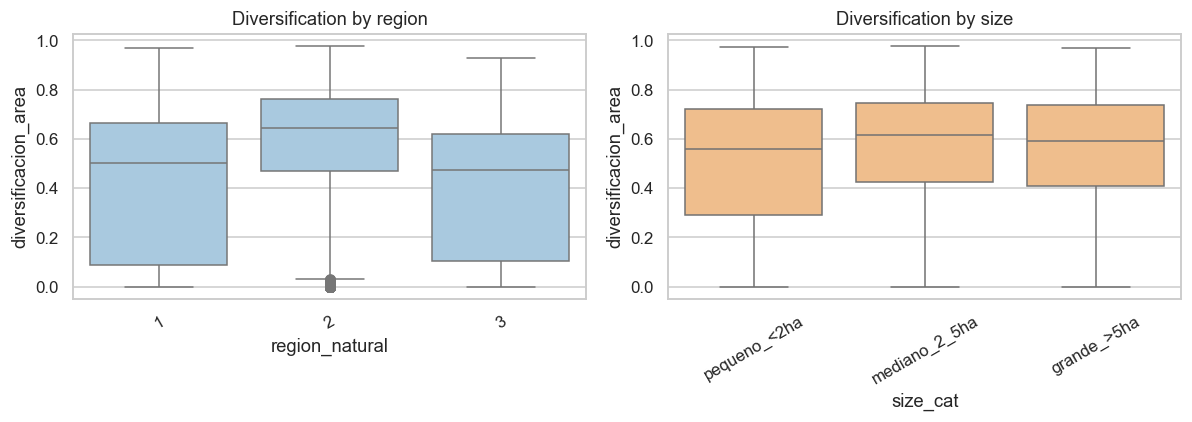

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(
    data=model,
    x="region_natural",
    y="diversificacion_area",
    ax=axes[0],
    color="#A0CBE8",
)
axes[0].set_title("Diversification by region")
axes[0].set_xlabel("region_natural")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(
    data=model,
    x="size_cat",
    y="diversificacion_area",
    ax=axes[1],
    color="#FFBE7D",
)
axes[1].set_title("Diversification by size")
axes[1].set_xlabel("size_cat")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_diversification_by_group.png", dpi=150)

## Output distributions and intensity

We examine the distribution of total value and value per hectare.

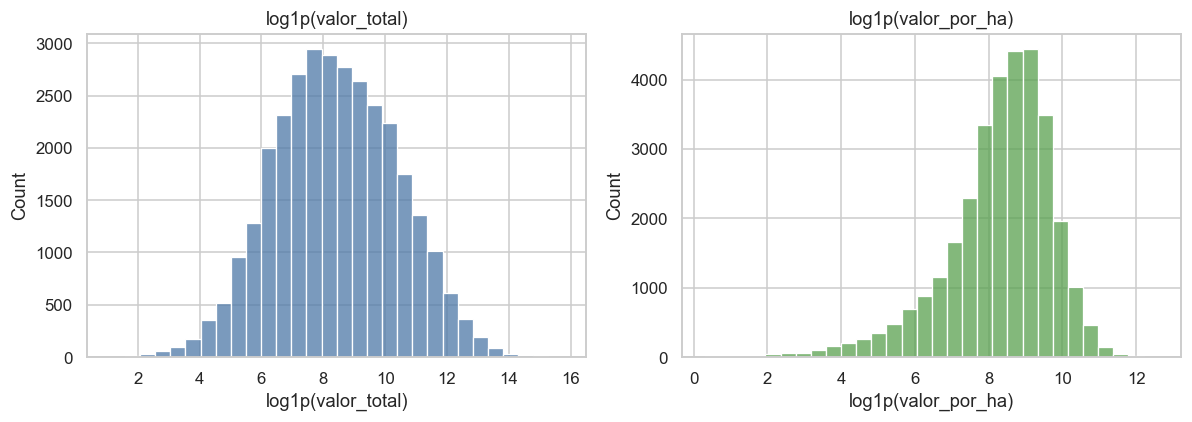

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pos_val = model.loc[model["valor_total"] > 0, "valor_total"]
sns.histplot(np.log1p(pos_val), bins=30, ax=axes[0], color="#4E79A7")
axes[0].set_title("log1p(valor_total)")
axes[0].set_xlabel("log1p(valor_total)")

val_per_ha = model["valor_por_ha"].dropna()
sns.histplot(np.log1p(val_per_ha), bins=30, ax=axes[1], color="#59A14F")
axes[1].set_title("log1p(valor_por_ha)")
axes[1].set_xlabel("log1p(valor_por_ha)")

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_output_distribution.png", dpi=150)

Higher output levels are heavily right-skewed; log transforms are helpful for
visualization and modeling.

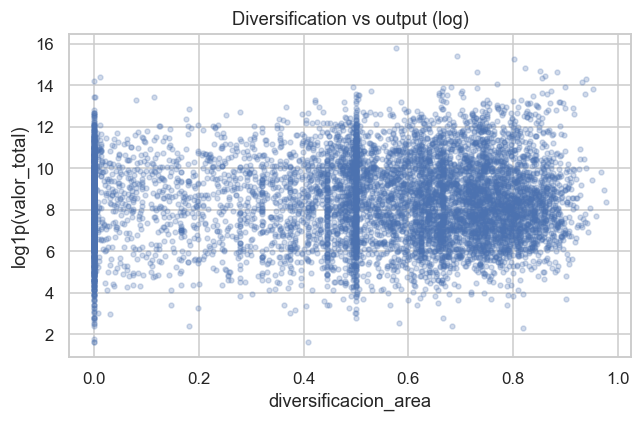

In [21]:
sample_df = model[["diversificacion_area", "log1p_valor_total"]].dropna().sample(
    n=min(8000, len(model)), random_state=RANDOM_SEED
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sample_df["diversificacion_area"], sample_df["log1p_valor_total"], alpha=0.25, s=10)
ax.set_xlabel("diversificacion_area")
ax.set_ylabel("log1p(valor_total)")
ax.set_title("Diversification vs output (log)")

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_diversification_vs_output.png", dpi=150)

## Labor and input costs

We inspect labor and input expenditures, both in levels and per hectare.

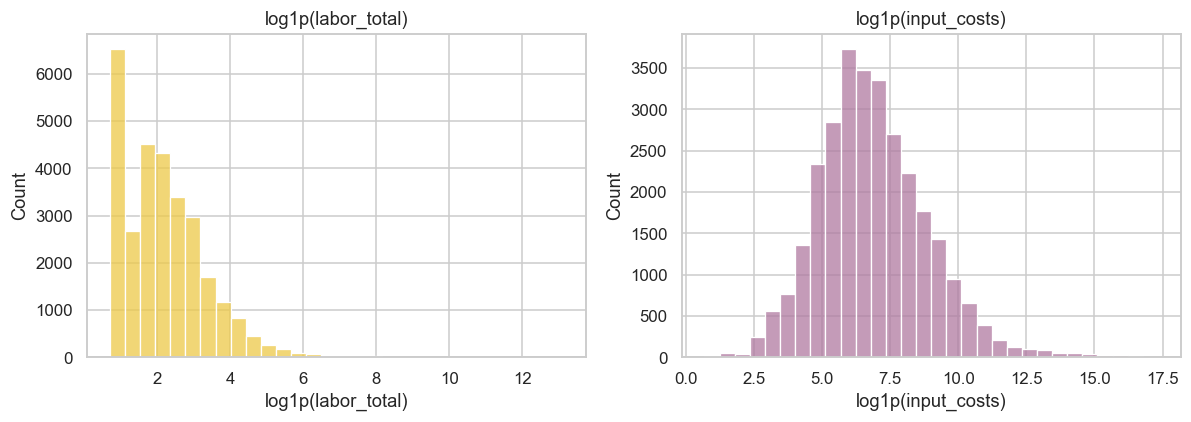

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(
    np.log1p(model["labor_total"].where(model["labor_total"] > 0)),
    bins=30,
    ax=axes[0],
    color="#EDC948",
)
axes[0].set_title("log1p(labor_total)")
axes[0].set_xlabel("log1p(labor_total)")

sns.histplot(
    np.log1p(model["input_costs"].where(model["input_costs"] > 0)),
    bins=30,
    ax=axes[1],
    color="#B07AA1",
)
axes[1].set_title("log1p(input_costs)")
axes[1].set_xlabel("log1p(input_costs)")

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_labor_inputs_distribution.png", dpi=150)

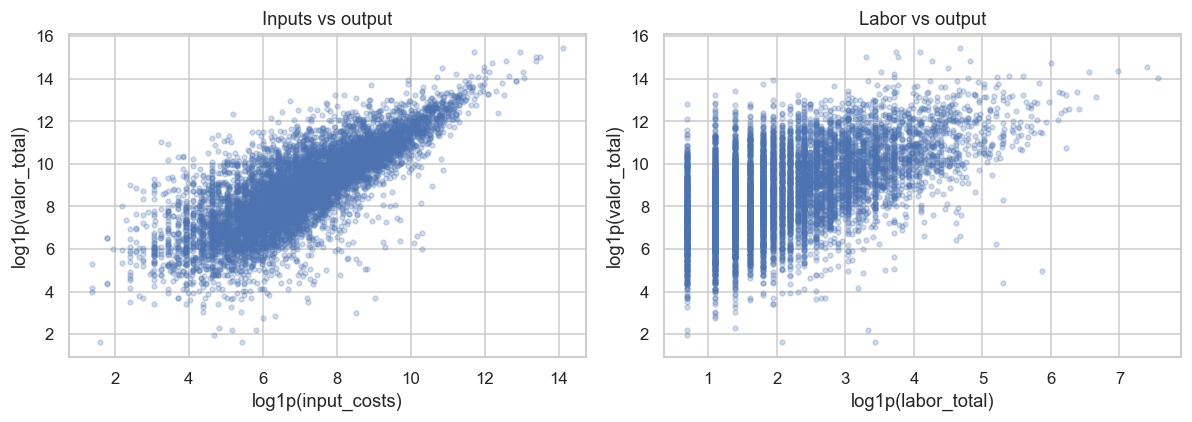

In [23]:
sample_df = model[["log1p_valor_total", "log1p_input_costs", "log1p_labor_total"]].dropna()
sample_df = sample_df.sample(n=min(8000, len(sample_df)), random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(sample_df["log1p_input_costs"], sample_df["log1p_valor_total"], alpha=0.25, s=10)
axes[0].set_xlabel("log1p(input_costs)")
axes[0].set_ylabel("log1p(valor_total)")
axes[0].set_title("Inputs vs output")

axes[1].scatter(sample_df["log1p_labor_total"], sample_df["log1p_valor_total"], alpha=0.25, s=10)
axes[1].set_xlabel("log1p(labor_total)")
axes[1].set_ylabel("log1p(valor_total)")
axes[1].set_title("Labor vs output")

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_labor_inputs_vs_output.png", dpi=150)

## Practice adoption

The practices variable is based on a subset of practices captured in CAP300.
We look at the distribution and group-level variation.

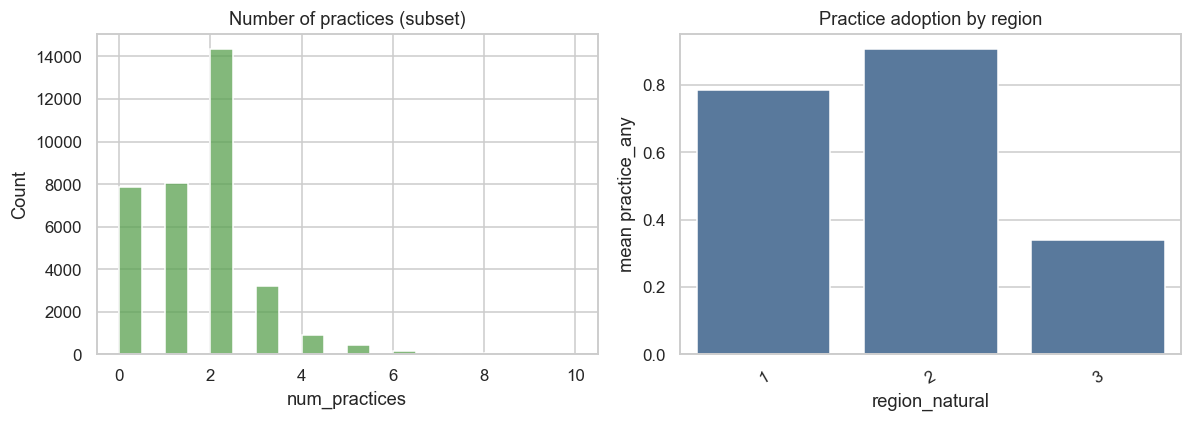

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(model["num_practices"], bins=20, ax=axes[0], color="#59A14F")
axes[0].set_title("Number of practices (subset)")
axes[0].set_xlabel("num_practices")

practice_rates = model.groupby("region_natural", dropna=False)["practice_any"].mean().reset_index()
sns.barplot(data=practice_rates, x="region_natural", y="practice_any", ax=axes[1], color="#4E79A7")
axes[1].set_title("Practice adoption by region")
axes[1].set_xlabel("region_natural")
axes[1].set_ylabel("mean practice_any")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_practices_distribution.png", dpi=150)

Practice adoption is heterogeneous across regions and size categories, which
suggests value in interactions or stratified models.

/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_31424/1857764800.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_practice = model.groupby("size_cat", dropna=False)["practice_any"].mean().reset_index()


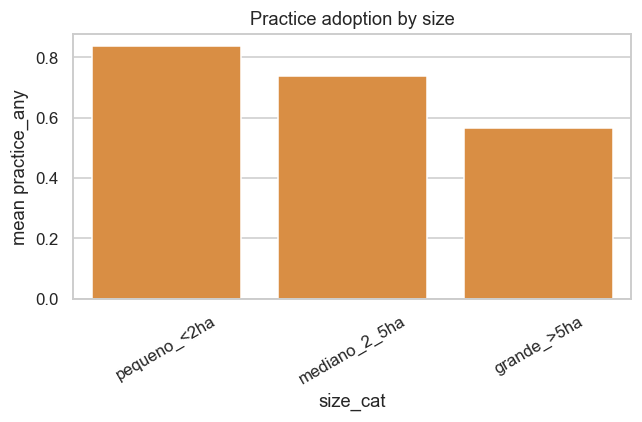

In [25]:
size_practice = model.groupby("size_cat", dropna=False)["practice_any"].mean().reset_index()
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=size_practice, x="size_cat", y="practice_any", ax=ax, color="#F28E2B")
ax.set_title("Practice adoption by size")
ax.set_xlabel("size_cat")
ax.set_ylabel("mean practice_any")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_practices_by_size.png", dpi=150)

## Output by diversification bins

Binning diversification helps identify non-linear patterns.

In [26]:
plot_df = model[["diversificacion_area", "log1p_valor_total"]].dropna()
plot_df = plot_df.loc[plot_df["diversificacion_area"].between(0, 1)]
plot_df = plot_df.assign(div_bin=pd.qcut(plot_df["diversificacion_area"], 5, duplicates="drop"))

bin_stats = plot_df.groupby("div_bin")["log1p_valor_total"].agg(["mean", "median", "count"]).reset_index()
bin_stats

/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_31424/844955809.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = plot_df.groupby("div_bin")["log1p_valor_total"].agg(["mean", "median", "count"]).reset_index()


,div_bin,mean,median,count
0,"(-0.001, 0.249]",8.234649,8.378161,6365
1,"(0.249, 0.5]",8.438595,8.469052,6722
2,"(0.5, 0.653]",8.523171,8.501267,6009
3,"(0.653, 0.754]",8.448055,8.289288,6363
4,"(0.754, 0.977]",8.416226,8.224432,6365


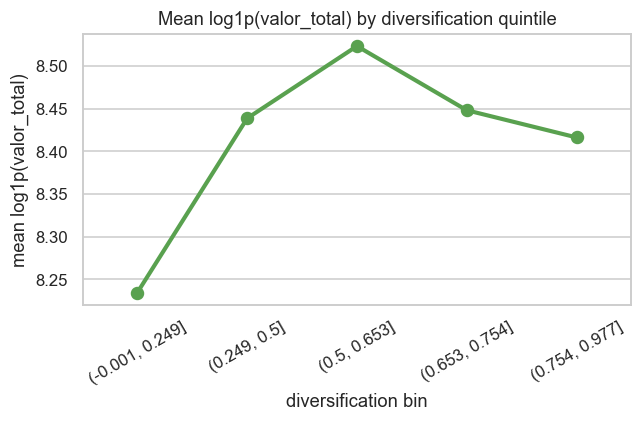

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.pointplot(data=bin_stats, x="div_bin", y="mean", ax=ax, color="#59A14F")
ax.set_title("Mean log1p(valor_total) by diversification quintile")
ax.set_xlabel("diversification bin")
ax.set_ylabel("mean log1p(valor_total)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_output_by_div_bins.png", dpi=150)

## Weighted vs unweighted regional means

ENA provides expansion weights. Comparing weighted and unweighted means can
reveal how sampling affects aggregate estimates.

In [28]:
weighted_vars = ["valor_total", "diversificacion_area", "practice_any", "input_costs"]

weighted_rows = []
for region, gdf in model.groupby("region_natural", dropna=False):
    row = {"region_natural": region, "n": len(gdf)}
    for var in weighted_vars:
        row[f"mean_{var}"] = float(gdf[var].mean())
        row[f"wmean_{var}"] = weighted_mean(gdf[var], gdf["weight"])
    weighted_rows.append(row)

weighted_summary = pd.DataFrame(weighted_rows)
weighted_summary

,region_natural,n,mean_valor_total,wmean_valor_total,mean_diversificacion_area,wmean_diversificacion_area,mean_practice_any,wmean_practice_any,mean_input_costs,wmean_input_costs
0,1,8263,70773.206750,61621.708816,0.422817,0.425163,0.784919,0.705189,119442.043335,15573.515007
1,2,20601,7172.153686,5673.604060,0.567544,0.582011,0.906408,0.911215,1591.367315,1101.856524
2,3,6323,46390.969010,42715.038072,0.394723,0.422017,0.339870,0.417235,19461.917496,5495.296055


## Controls analysis (irrigation, machinery, seeds, services)

When the plus-controls dataset is available, we summarize key controls and
their prevalence. Missing indicators help identify reporting gaps.

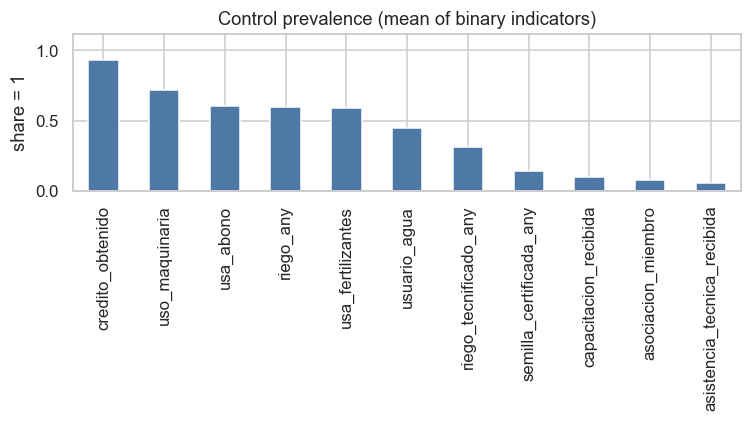

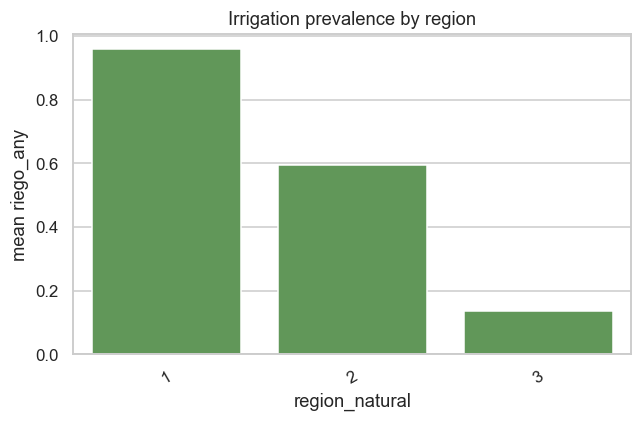

In [29]:
if controls_loaded:
    ctrl = model_ctrl.copy()

    control_vars = [
        "riego_any",
        "riego_tecnificado_any",
        "usuario_agua",
        "uso_maquinaria",
        "semilla_certificada_any",
        "usa_abono",
        "usa_fertilizantes",
        "capacitacion_recibida",
        "asistencia_tecnica_recibida",
        "credito_obtenido",
        "asociacion_miembro",
    ]

    prevalence = (
        ctrl[control_vars]
        .apply(pd.to_numeric, errors="coerce")
        .mean()
        .sort_values(ascending=False)
    )
    prevalence

    fig, ax = plt.subplots(figsize=(7, 4))
    prevalence.plot(kind="bar", ax=ax, color="#4E79A7")
    ax.set_title("Control prevalence (mean of binary indicators)")
    ax.set_ylabel("share = 1")
    ax.set_ylim(0, max(0.05, prevalence.max() * 1.2))
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOT_DIR / "eda_controls_prevalence.png", dpi=150)

    riego_by_region = (
        ctrl.groupby("region_natural", dropna=False)["riego_any"].mean().reset_index()
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=riego_by_region, x="region_natural", y="riego_any", ax=ax, color="#59A14F")
    ax.set_title("Irrigation prevalence by region")
    ax.set_xlabel("region_natural")
    ax.set_ylabel("mean riego_any")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOT_DIR / "eda_irrigation_by_region.png", dpi=150)
else:
    print("Controls dataset not available; skipping controls analysis.")

## Correlation scan (selected numeric variables)

This is a quick diagnostic to see broad relationships among core metrics.

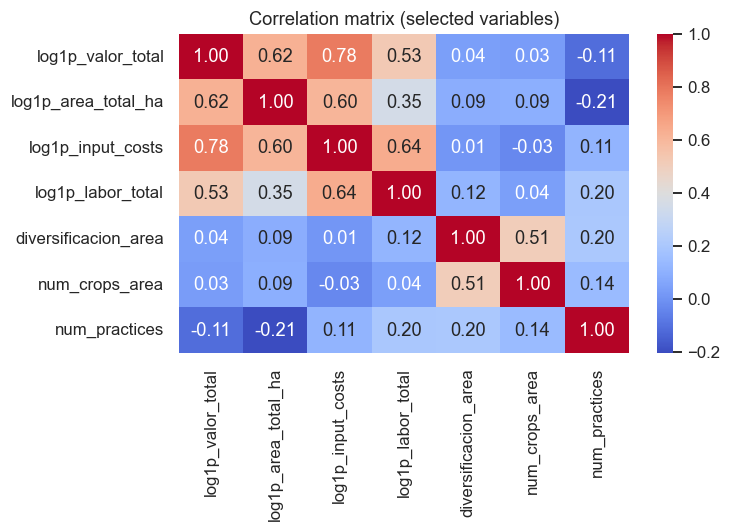

In [30]:
num_vars = [
    "log1p_valor_total",
    "log1p_area_total_ha",
    "log1p_input_costs",
    "log1p_labor_total",
    "diversificacion_area",
    "num_crops_area",
    "num_practices",
]

corr_df = model[num_vars].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix (selected variables)")
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "eda_correlation_heatmap.png", dpi=150)

## Interpretation

- Diversification shows a pronounced mass at zero, consistent with monocrop
  production (HHI = 1). This is visible in both the histogram and the monocrop
  share diagnostic.
- Output, input costs, and labor are heavily right-skewed; log transforms are
  appropriate for modeling and visualization.
- Practice adoption differs by region and size, suggesting heterogeneity that
  could be captured with interactions or stratified models.
- Control variables (irrigation, machinery, seed use, training/credit) display
  varied prevalence; some are rare and may require careful handling in models.
- Weighted vs unweighted means can diverge, indicating that expansion weights
  matter for population-level inference.

Next steps could include formal modeling of log output on diversification,
inputs, labor, and controls, plus robustness checks by region and size.